In [16]:
from langgraph.graph.state import StateGraph, START, END
from state import BlogAgentState
from nodes.router import router_node
from nodes.summarizer import summarizer_node
from nodes.research_query_gen import research_query_gen_node
from nodes.planner import planner_node
from nodes.writer import task_executer_node
from nodes.assembler import assembler_node
from nodes.editor import editor_node
from nodes.finalize import finalize_node
from nodes.critic import critic_node
from nodes.research_loop import research_loop_node

In [17]:
graph = StateGraph(BlogAgentState)

In [18]:
# nodes
graph.add_node("router_node",router_node)
graph.add_node("research_query_gen_node",research_query_gen_node)
graph.add_node("summarizer_node", summarizer_node)
graph.add_node("research_loop",research_loop_node)
graph.add_node("planner_node", planner_node)
graph.add_node("task_executer_node", task_executer_node)
graph.add_node("assembler_node", assembler_node)
graph.add_node("editor_node", editor_node)
graph.add_node("critic_node", critic_node)
graph.add_node("finalize_node", finalize_node)


graph.add_edge(START, "router_node")

def route_research(state:BlogAgentState):
    if state.needs_research:
        return "research_query_gen_node"
    else:
        return "summarizer_node"

graph.add_conditional_edges("router_node", route_research,
                            {
                                "research_query_gen_node": "research_query_gen_node",
                                "summarizer_node": "summarizer_node"
                            })

def needs_revision(state:BlogAgentState):
    if state.needs_revision:
        return "task_executer_node"
    else:
        return "finalize_node"

def needs_research(state:BlogAgentState):
    if state.more_research_needed:
        return "router_node"
    else:
        return "planner_node"

graph.add_conditional_edges("critic_node", needs_revision,
                            {
                                "task_executer_node": "task_executer_node",
                                "finalize_node": "finalize_node"
                            })

graph.add_conditional_edges("research_loop", needs_research, {
    "router_node": "router_node",
    "planner_node": "planner_node"
})


# edges
graph.add_edge("research_query_gen_node", "research_loop")
graph.add_edge("summarizer_node", "research_loop")
graph.add_edge("research_loop", "planner_node")
graph.add_edge("planner_node", "task_executer_node")
graph.add_edge("task_executer_node", "assembler_node")
graph.add_edge("assembler_node", "editor_node")
graph.add_edge("editor_node",'critic_node')

graph.add_edge("critic_node", "finalize_node")
graph.add_edge("finalize_node",END)

workflow = graph.compile()

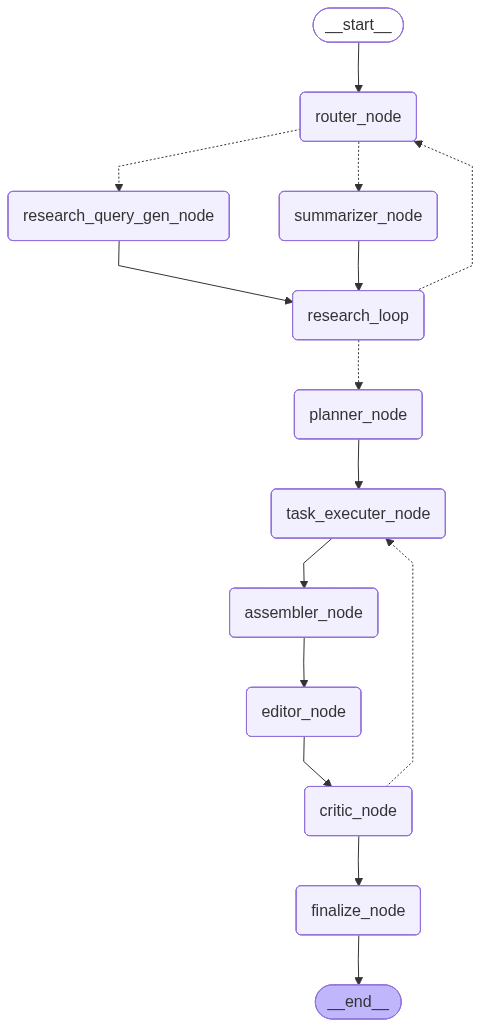

In [19]:
workflow

In [20]:
from workflow import workflow

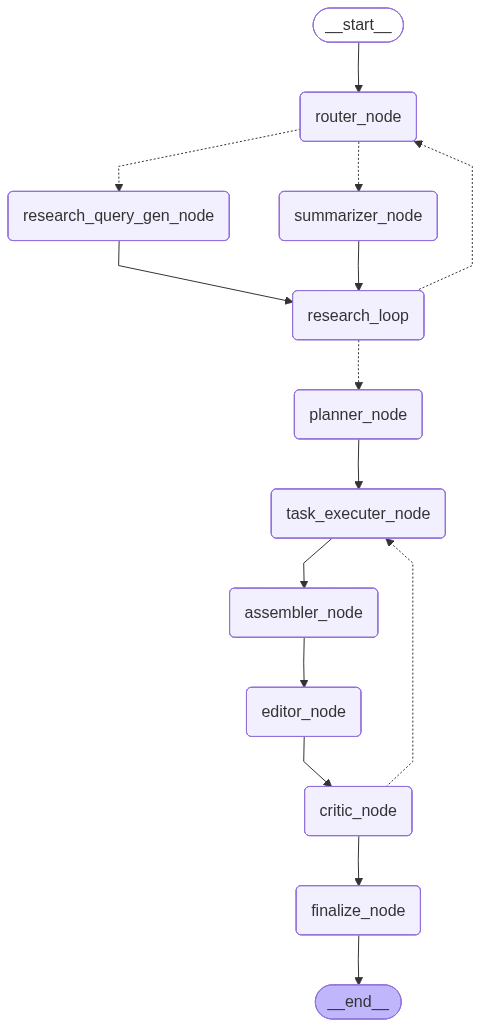

In [21]:
workflow